# 数据分布1——直方图&核密度

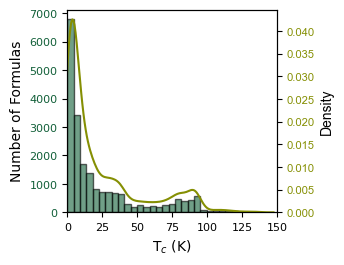

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

color2 = '#858F03'   #density
color1 = '#115F38'   #histogram
# 读取数据
file_path = '../../Data/mdr_clean.csv'
df = pd.read_csv(file_path)

# 处理数据，替换无穷大值为NaN，并删除NaN值
data = df['Tc'].replace([np.inf, -np.inf], np.nan).dropna().tolist()

# 创建图表
fig_height = 7  #cm
fig_width = 9 #cm
fig, ax1 = plt.subplots(figsize=(fig_width/2.54, fig_height/2.54))
plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
# 绘制直方图
ax1.hist(data, bins=30, color=color1, alpha=0.6, edgecolor='black')
ax1.set_xlabel(r'T$_c$ (K)', fontsize=10)
ax1.set_ylabel('Number of Formulas', color='black', size=10)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=8)

# 创建第二个轴，共享同一个X轴
ax2 = ax1.twinx()

# 绘制KDE
sns.kdeplot(data, ax=ax2, color=color2, fill=False)
ax2.set_ylabel('Density', color='black', size=10)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=8)

# 设置X轴参数
ax1.tick_params(axis='x', labelsize=8)
ax1.set_xlim(0, 150)

# 保存和显示图表
plt.tight_layout()
plt.savefig('../../Pic/Pic/Fig2a_a4.svg', bbox_inches='tight',transparent=True)
plt.savefig('../../Pic/Pic/Fig2a_a4.tif', dpi=600, bbox_inches='tight',transparent=True)
plt.show()

# 绘制预测结果

## 元素数量

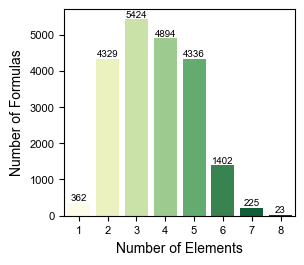

Formulas with 8 elements:
2130            Bi0.6Pb0.2S0.2Sr2Ca0.7Nd0.3Cu2O6.95
2879            Bi0.2Pb0.4S0.4Sr2Ca0.7Nd0.3Cu2O6.99
3082         Ca5.9Sr3.5Bi0.3Y0.1Pb0.1Al0.1Cu15.1O29
3093            Bi0.8Pb0.1S0.1Sr2Ca0.7Nd0.3Cu2O6.95
3094          Bi0.5Pb0.25S0.25Sr2Ca0.7Nd0.3Cu2O6.97
3280     La2.3Gd0.7Ca1Ba2.8Sr0.2Cu6.86In0.14O16.536
4255           Bi1.7Pb0.3Sr2Ca0.7Y0.3Cu1.94Zn0.06O8
4328      La2.1Gd0.9Ca1Ba2.6Sr0.4Cu6.72In0.28O16.54
4451         Bi1.7Pb0.3Sr2Ca0.65Y0.35Cu1.94Zn0.06O8
4526         Bi1.7Pb0.3Sr2Ca0.75Y0.25Cu1.94Zn0.06O8
5460     La1.9Gd1.1Ca1Ba2.4Sr0.6Cu6.58In0.42O16.554
5624           Bi1.7Pb0.3Sr2Ca0.8Y0.2Cu1.94Zn0.06O8
5667           Bi1.7Pb0.3Sr2Ca0.6Y0.4Cu1.94Zn0.06O8
6766             Pb0.5Cd0.5Sr1.5Ba0.5Ca0.5Y0.5Cu2O7
7185         Bi1.7Pb0.3Sr2Ca0.55Y0.45Cu1.94Zn0.06O8
9010             Pb0.5Cd0.5Sr1.6Ba0.4Ca0.5Y0.5Cu2O7
9944       La1.7Gd1.3Ca1Ba2.2Sr0.8Cu6.44In0.56O16.6
16350             Tl0.6Pb0.2Bi0.2Sr1.8Ba0.2Ca2Cu3O9
16675                Bi0.8Nd0.1Tb0.1Pb

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 读取Excel文件的指定列
file_path = '../../Data/mdr_clean.csv'
column = 'formula'

# 使用pandas读取Excel文件的指定列
df = pd.read_csv(file_path)

# 定义一个函数来计算分子式中元素的数量
def count_elements(formula):
    # 使用正则表达式匹配所有元素，考虑到元素后面可能紧跟数字
    elements = re.findall(r'[A-Z][a-z]*', formula)
    return len(elements)

# 应用函数并创建一个新的列来存储每个分子式的元素数量
df['element_count'] = df[column].apply(lambda x: count_elements(str(x)) if pd.notnull(x) else 0)

# 统计不同元素数量的分子式数量
element_counts = df['element_count'].value_counts()

# 绘制图表表现数据的分布
fig_height = 7  #cm
fig_width = 8 #cm
plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
plt.figure(figsize=(fig_width/2.54, fig_height/2.54))
barplot = sns.barplot(x=element_counts.index, y=element_counts.values, hue=element_counts.index, palette="YlGn", legend=False)
# 添加文本注释
for i, (element_count, value) in enumerate(element_counts.items()):
    plt.text(element_count-1,value, str(value), ha='center', va='bottom',fontsize=7)

plt.xlabel('Number of Elements', fontsize=10)
plt.ylabel('Number of Formulas', fontsize=10)
plt.xticks(fontsize=8)  # 确保所有的x轴标签都能显示
plt.yticks(fontsize=8)  # 设置y轴标签的字体大小
# 保存和显示图表
plt.tight_layout()
plt.savefig('../../Pic/Pic/Fig2b_a4.svg',bbox_inches='tight',transparent=True)
plt.savefig('../../Pic/Pic/Fig2b_a4.tif', dpi=600,bbox_inches='tight',transparent=True)
plt.show()

# 筛选出元素数量等于一定数量的行
formulas_with_ten_elements = df[df['element_count'] == 8][column]

# 输出这些分子式
print("Formulas with 8 elements:")
print(formulas_with_ten_elements)

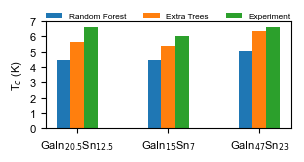

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 数据
data = {
    'LM-based material': ['GaIn$_{20.5}$Sn$_{12.5}$', 'GaIn$_{15}$Sn$_7$', 'GaIn$_{47}$Sn$_{23}$'],
    'RF-Tc (K)': [4.44, 4.48, 5.07],
    'ET-Tc (K)': [5.66, 5.39, 6.37],
    'Tc (K)': [6.6, 6.0, 6.6]
}

# 创建DataFrame
df = pd.DataFrame(data)

# 设置条形图的位置和宽度
n = len(df)
bar_width = 0.15
index = np.arange(n)

# 绘制条形图
fig_height = 4.5  #cm
fig_width = 8 #cm
plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
fig, ax = plt.subplots(figsize=(fig_width/2.54, fig_height/2.54))

# 绘制每个条形
bar1 = ax.bar(index, df['RF-Tc (K)'], bar_width, label='Random Forest')
bar2 = ax.bar(index + bar_width, df['ET-Tc (K)'], bar_width, label='Extra Trees')
bar3 = ax.bar(index + 2 * bar_width, df['Tc (K)'], bar_width, label='Experiment')

# 设置x轴标签
ax.set_xticks(index + bar_width)
ax.set_xticklabels(df['LM-based material'], rotation=0, ha='center',fontsize=8)

# 设置y轴标签
ax.set_ylabel('T$_c$ (K)', fontsize=8)
ax.set_ylim(0, 7)  # 设置y轴范围为0到7
plt.yticks(np.arange(0, 8, 1), fontsize=8)  # 设置y轴刻度为0到7

# 添加图例并移动位置
# ax.legend(loc='upper right', bbox_to_anchor=(0.548, 1.02),fontsize=6,framealpha=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), fontsize=6, framealpha=0, ncol=3)

# 显示图表
plt.tight_layout()
# 保存图表
plt.savefig('../../Pic/Pic/Fig5d_a4.svg',  bbox_inches='tight', transparent=True)
plt.savefig('../../Pic/Pic/Fig5d_a4.tif', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# 数据预测准确度与残差

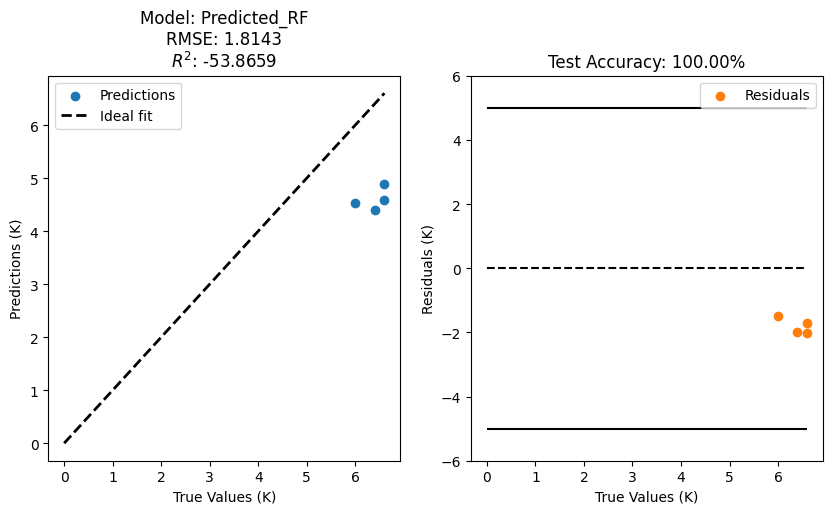

In [2]:
# 描述数据预测准确度与残差
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


file_path = '../../Code/1_Tree_model_train/3-prediction/updated_mdr_RF.csv'
data = pd.read_csv(file_path)

def right_count(y_pred, y_true):
    relative_error = abs(y_pred - y_true)
    return (relative_error < 5).sum().item()

# 绘制散点图
def performancecalculator(trueVals, predVals, name):
    plt.figure(figsize=(10, 5)) 
    
    plt.subplot(1, 2, 1)
    plt.scatter(trueVals, predVals, color='#1f77b4', label='Predictions')
    max_val = trueVals.max()
    plt.plot([0, max_val], [0, max_val], 'k--', lw=2, label='Ideal fit')
    
    er = mean_squared_error(trueVals, predVals)
    er = pow(er, 0.5)
    er = int(er * 10000) / 10000
    r2 = r2_score(trueVals, predVals)
    plt.title(f'Model: {name}\n'
              f'RMSE: {er:.4f}\n'
              f'$R^2$: {r2:.4f}')
    plt.legend()
    plt.xlabel('True Values (K)')
    plt.ylabel('Predictions (K)')

    plt.subplot(1, 2, 2)
    residuals = predVals - trueVals 
    plt.scatter(trueVals, residuals, color='#ff7f0e', label='Residuals')
    plt.hlines(y=0, xmin=0, xmax=max_val, colors='black', linestyles='dashed')
    plt.hlines(y=-5, xmin=0, xmax=max_val, colors='black')
    plt.hlines(y=5, xmin=0, xmax=max_val, colors='black')

    plt.xlabel('True Values (K)')
    plt.ylabel('Residuals (K)')
    plt.title(f"Test Accuracy: {right_count(predVals,trueVals) / len(predVals) * 100:.2f}%")
    plt.legend()
    plt.margins(x=0.05, y=0.1)
    plt.show()
    
    
name = 'Predicted_RF'
performancecalculator(data['Tc'], data['Predicted_RF'], name)